# Accessing the core spectrograph and detector parameters

Behind every Lazuli target is a `slicersim.Simulation` object, which holds the instrument
model (telescope, spectrograph, detector) and the scene. This notebook shows how to access
some of its key quantities: the detector quantum efficiency, the spectral resolution and the
effective transmission.

In [1]:
import slicersim

Let us load a SN Ia target and access its `simulation` attribute.

In [2]:
lazuli_snia = slicersim.LazuliSupernova(redshift=1)

In [3]:
# the simulation is where everything happens
simulation = lazuli_snia.simulation

## Quantum efficiency

`detector.qe` is a function of wavelength (in Å) returning the detector quantum efficiency.

In [4]:
lbda = simulation.spectrograph.lbda
qe = simulation.detector.qe

Text(0, 0.5, 'quantum efficiency')

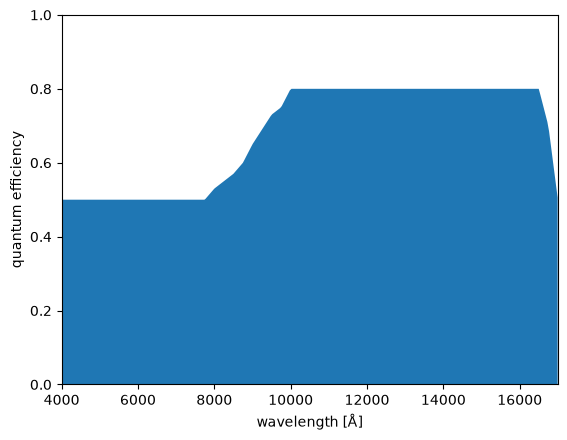

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.fill_between(lbda, qe(lbda))
ax.set_ylim(0, 1)
ax.set_xlim(lbda[0], lbda[-1])
ax.set_xlabel("wavelength [Å]")
ax.set_ylabel("quantum efficiency")

## Spectral resolution

The resolving power R = λ/Δλ is computed from the wavelength binning, Δλ being the size
of a resolution element, i.e. `dispersion_resolution` wavelength bins
(this is also what `spectrograph.get_resolving_power()` returns). The dashed line shows R=100.

Text(0, 0.5, 'resolving power R')

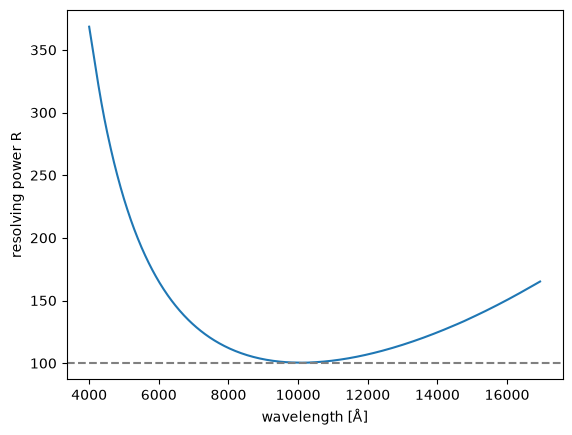

In [6]:
import numpy as np
fig, ax = plt.subplots()
ax.plot(lbda[:-1], lbda[:-1] / (simulation.spectrograph.dispersion_resolution * np.diff(lbda)))
ax.axhline(100, ls="--", color="0.5")
ax.set_xlabel("wavelength [Å]")
ax.set_ylabel("resolving power R")

## Effective transmission

`get_effective_transmission()` returns the conversion factor between the input flux
(in erg/s/cm²/Å) and the signal recorded by the detector, in ADU, for the current
configuration.

In [7]:
lbda, transmission = simulation.get_effective_transmission()

(0.0, 2.0259816537357396e+20)

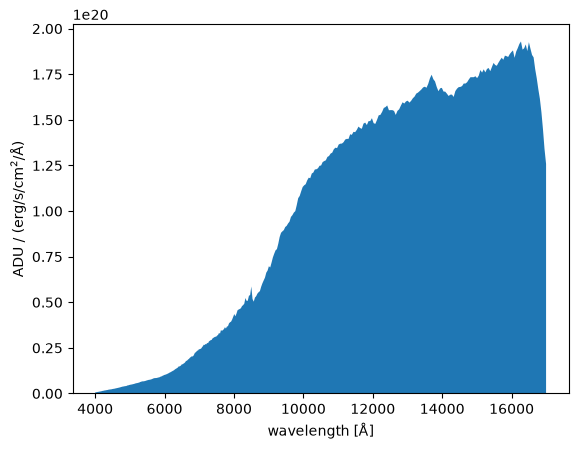

In [8]:
fig, ax = plt.subplots()

ax.fill_between(lbda, transmission)
ax.set_xlabel("wavelength [Å]")
ax.set_ylabel("ADU / (erg/s/cm$^2$/Å)")
ax.set_ylim(0)